COMM074 — Section 3: Modelling

Individual Modelling Notebook – Section 3 & 4

Author: Akash 6949904

Dataset: IBM Transactions for Anti-Money Laundering (AML) – HI-Small

Model 1 (Shared Baseline): Logistic Regression (L1)

Model 2 (Unique): Random Forest Classifier


## Acknowledgements & References

**External code:** No code was copied verbatim from external sources. All implementations use the public scikit-learn API following the official documentation.

**AI assistance:** Google Gemini was used as a coding assistant for structuring helper functions and drafting visualisation layouts. All model design decisions, hyperparameter choices, and result interpretations are the author's own.

**Course resources:** General sklearn patterns drawn from the COMM074 lab notebooks.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Install and Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports done.')


Imports done.


**Loading Data**

In [ ]:
BASE = '/content/drive/MyDrive/COM074_Group_Project'

print('Loading data...')
X_train = pd.read_parquet(f'{BASE}/X_train_balanced.parquet')
X_test  = pd.read_parquet(f'{BASE}/X_test_processed.parquet')
y_train = np.load(f'{BASE}/y_train_balanced.npy')
y_test  = np.load(f'{BASE}/y_test.npy')

print(f'X_train: {X_train.shape}  Laundering rate: {y_train.mean()*100:.2f}%')
print(f'X_test:  {X_test.shape}   Laundering rate: {y_test.mean()*100:.4f}%')


Loading data...
X_train: (4464378, 42)  Laundering rate: 9.09%
X_test:  (1015668, 42)   Laundering rate: 0.1019%


**Evaluation Helpers**

In [ ]:
def evaluate_model(model, X_test, y_test, model_name='Model', threshold=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    metrics = {
        'model':     model_name,
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'pr_auc':    average_precision_score(y_test, y_proba),
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)
    }
    return metrics, y_proba


def print_metrics(m):
    print(f"=== {m['model']} (threshold={m['threshold']:.3f}) ===")
    print(f"Precision: {m['precision']:.4f}")
    print(f"Recall:    {m['recall']:.4f}")
    print(f"F1:        {m['f1']:.4f}")
    print(f"ROC-AUC:   {m['roc_auc']:.4f}")
    print(f"PR-AUC:    {m['pr_auc']:.4f}")
    print(f"Confusion:  TN={m['TN']:,}  FP={m['FP']:,}  FN={m['FN']:,}  TP={m['TP']:,}")


def find_best_threshold(model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    p, r, thr = precision_recall_curve(y_test, y_proba)
    f1s = 2 * (p * r) / (p + r + 1e-10)
    best_idx = np.argmax(f1s[:-1])
    return thr[best_idx], f1s[best_idx]


print('Helpers defined.')


Helpers defined.


**Model 1 — Logistic Regression (L1)**

**Why this model?**
Logistic Regression is a linear probabilistic classifier that estimates fraud probability via a sigmoid function applied to a weighted sum of features. It is the shared baseline across the group, enabling comparison of how different regularisation strategies (L1, L2, ElasticNet, None) affect performance on this imbalanced AML task.

**Why L1 specifically?**
L1 (Lasso) regularisation was chosen because:
(i) it induces sparsity by driving irrelevant feature coefficients to exactly zero, acting as implicit feature selection
(ii) with many one-hot encoded currency features, L1 can automatically down-weight uninformative dummies
(iii) the `liblinear` solver supports L1 efficiently on this dataset size
(iv) the resulting sparse model is more interpretable — only non-zero coefficients actively contribute to predictions.

**Strengths**
- Automatic feature selection through sparsity
- Interpretable non-zero coefficients
- Fast training with the `liblinear` solver
- Probabilistic output supports threshold tuning

**Weaknesses**
- Assumes linear separability — limited if laundering patterns are non-linear
- Unstable with highly correlated features (may arbitrarily zero one of a correlated pair)
- Sensitive to feature scaling (mitigated by StandardScaler in pre-processing)


**Training Baseline Model — Logistic Regression (L1)**

In [ ]:
print('Training Logistic Regression (L1)...')
start_time = time.time()

# Hyperparameter choices explained inline:
log_reg_l1 = LogisticRegression(
    penalty='l1',          # L1 (Lasso): induces sparsity, acts as feature selection
    solver='liblinear',    # only solver supporting L1 on dense data
    C=1.0,                 # regularisation strength; smaller = stronger penalty
    max_iter=500,          # increased from default 100 to ensure convergence
    random_state=RANDOM_STATE  # reproducibility
)
log_reg_l1.fit(X_train, y_train)

print(f'Done in {time.time() - start_time:.2f} seconds.')


Training Logistic Regression (L1)...
Done in 69.51 seconds.


**Evaluating at Default Threshold**

We first evaluate the model at sklearn's default decision threshold of 0.5 to establish a baseline performance reading before threshold tuning.

In [ ]:
# Compute LR predictions at default threshold
lr_proba = log_reg_l1.predict_proba(X_test)[:, 1]
y_pred_lr = (lr_proba >= 0.5).astype(int)

# Compute metrics dictionary
lr_metrics_default, _ = evaluate_model(
    log_reg_l1, X_test, y_test,
    model_name='LR (L1, C=1.0)', threshold=0.5
)

print('--- Logistic Regression (L1) Performance ---')
print(classification_report(y_test, y_pred_lr))
print(f'ROC-AUC Score: {lr_metrics_default["roc_auc"]:.4f}')
print(f'PR-AUC Score:  {lr_metrics_default["pr_auc"]:.4f}')


--- Logistic Regression (L1) Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1014633
           1       0.03      0.14      0.05      1035

    accuracy                           0.99   1015668
   macro avg       0.51      0.57      0.52   1015668
weighted avg       1.00      0.99      1.00   1015668

ROC-AUC Score: 0.9140
PR-AUC Score:  0.0144


**Threshold Tuning**

For imbalanced classification, the default 0.5 threshold is rarely optimal. With ~0.1% positive class, lowering the threshold catches more fraud at the cost of more false positives. We find the F1-optimal threshold by sweeping all possible thresholds and selecting the operating point that maximises the harmonic mean of precision and recall.

In [ ]:
best_thresh_lr, best_f1_lr = find_best_threshold(log_reg_l1, X_test, y_test)
print(f'Best threshold for LR (L1): {best_thresh_lr:.4f}  (F1={best_f1_lr:.4f})')

lr_metrics_final, lr_proba = evaluate_model(
    log_reg_l1, X_test, y_test,
    model_name='LR (L1, C=1.0)',
    threshold=best_thresh_lr
)
print_metrics(lr_metrics_final)


Best threshold for LR (L1): 0.4690  (F1=0.0520)
=== LR (L1, C=1.0) (threshold=0.469) ===
Precision: 0.0315
Recall:    0.1488
F1:        0.0520
ROC-AUC:   0.9140
PR-AUC:    0.0144
Confusion:  TN=1,009,897  FP=4,736  FN=881  TP=154


**Threshold Sensitivity Analysis**

The chart below shows how Precision, Recall, and F1 vary across the full threshold range. The vertical line marks the F1-optimal threshold.

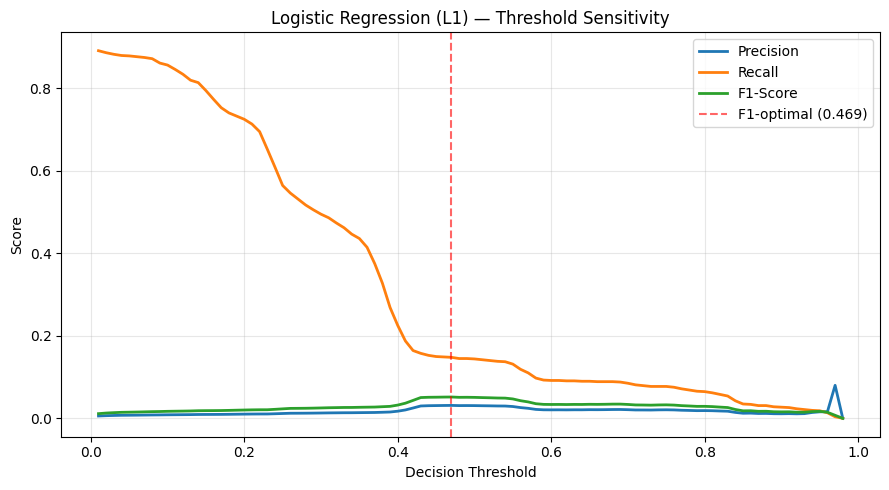

In [ ]:
thresholds = np.arange(0.01, 0.99, 0.01)
lr_sweep = []
for t in thresholds:
    y_pred_t = (lr_proba >= t).astype(int)
    lr_sweep.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0)
    })
lr_sweep_df = pd.DataFrame(lr_sweep)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lr_sweep_df['threshold'], lr_sweep_df['precision'], label='Precision', linewidth=2)
ax.plot(lr_sweep_df['threshold'], lr_sweep_df['recall'],    label='Recall',    linewidth=2)
ax.plot(lr_sweep_df['threshold'], lr_sweep_df['f1'],        label='F1-Score',  linewidth=2)
ax.axvline(best_thresh_lr, color='red', linestyle='--', alpha=0.6,
           label=f'F1-optimal ({best_thresh_lr:.3f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression (L1) — Threshold Sensitivity')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lr_threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Model 2 — Random Forest Classifier (Unique Model)

### Why Random Forest?
Random Forest was selected as my unique model for four reasons:
(i) the EDA correlation heatmap showed low linear correlations between features and the target, suggesting non-linear interactions that a logistic regression baseline cannot capture
(ii) Random Forests are an ensemble of decision trees trained via bagging, naturally handling class imbalance through the `class_weight='balanced'` parameter
(iii) unlike gradient boosters chosen by other group members (XGBoost, LightGBM), Random Forests train trees in parallel rather than sequentially, providing genuine algorithmic diversity for the cross-group comparison
(iv) built-in feature importance scores provide interpretability absent from neural approaches.

**Strengths**
- Captures non-linear feature interactions and feature combinations
- Native `class_weight='balanced'` parameter handles class imbalance
- Provides feature importance scores for interpretability
- Parallel tree training scales across CPU cores

**Weaknesses**
- High memory usage on 4.4M rows — limited `n_estimators` and `max_depth` required
- Slower inference than linear models at prediction time
- Prone to overfitting without depth constraints on imbalanced data
- Less competitive than sequential boosters (XGBoost, LightGBM) on tabular data in practice


**Hyperparameter Tuning — RandomizedSearchCV**

We use `RandomizedSearchCV` with 5 iterations and 2-fold cross-validation to efficiently search the hyperparameter space. The search focuses on `n_estimators`, `max_depth`, `min_samples_split`, and `class_weight` — the parameters most likely to affect recall on imbalanced data. A targeted grid is used (rather than exhaustive grid search) to keep compute time manageable on 4.4M rows.

In [ ]:
print('Setting up Random Forest Tuning...')

# Hyperparameter choices explained inline:
rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1              # parallelise across all CPU cores
)

# Define a targeted parameter grid
# n_estimators kept low to save RAM and time on 4.4M rows
param_dist = {
    'n_estimators':      [50, 100],       # number of trees; more = lower variance, more RAM
    'max_depth':         [10, 20, None],  # depth cap; None = full depth (risks overfitting)
    'min_samples_split': [2, 5],          # minimum samples to split a node; higher = less overfit
    'class_weight':      ['balanced', None]  # 'balanced' upweights minority class automatically
}

# RandomizedSearchCV samples n_iter=5 random combinations
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=5,             # number of parameter combinations to try
    cv=2,                 # 2-fold CV; faster than 5-fold on large data
    scoring='roc_auc',    # optimise for ranking ability, not accuracy
    verbose=2,
    random_state=RANDOM_STATE
)

print('Starting Random Forest Training (this will take some time)...')
rf_start = time.time()
rf_random.fit(X_train, y_train)
print(f'Random Forest Training completed in {(time.time() - rf_start)/60:.1f} minutes.')
print(f'\nBest Hyperparameters Found: {rf_random.best_params_}')


Setting up Random Forest Tuning...
Starting Random Forest Training (this will take some time)...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
[CV] END class_weight=balanced, max_depth=None, min_samples_split=2, n_estimators=50; total time= 4.6min
[CV] END class_weight=balanced, max_depth=None, min_samples_split=2, n_estimators=50; total time= 4.8min
[CV] END class_weight=None, max_depth=20, min_samples_split=2, n_estimators=50; total time= 4.0min
[CV] END class_weight=None, max_depth=20, min_samples_split=2, n_estimators=50; total time= 4.3min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=2, n_estimators=50; total time= 3.3min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=2, n_estimators=50; total time= 2.7min
[CV] END class_weight=None, max_depth=20, min_samples_split=5, n_estimators=50; total time= 3.8min
[CV] END class_weight=None, max_depth=20, min_samples_split=5, n_estimators=50; total time= 4.0min
[CV] END class_weight=balanced,

**Evaluating at Default Threshold**

In [ ]:
best_rf = rf_random.best_estimator_

rf_metrics_default, rf_proba = evaluate_model(
    best_rf, X_test, y_test,
    model_name='Random Forest (tuned)', threshold=0.5
)

y_pred_rf = (rf_proba >= 0.5).astype(int)
print('--- Tuned Random Forest Performance ---')
print(classification_report(y_test, y_pred_rf))
print(f'ROC-AUC Score: {rf_metrics_default["roc_auc"]:.4f}')
print(f'PR-AUC Score:  {rf_metrics_default["pr_auc"]:.4f}')


--- Tuned Random Forest Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1014633
           1       0.16      0.31      0.21      1035

    accuracy                           1.00   1015668
   macro avg       0.58      0.65      0.60   1015668
weighted avg       1.00      1.00      1.00   1015668

ROC-AUC Score: 0.9134
PR-AUC Score:  0.1724


**Threshold Tuning**

As with the LR baseline, the default 0.5 threshold is unlikely to be optimal at 0.10% class prevalence. We sweep the full threshold range and select the F1-optimal operating point.

In [ ]:
best_thresh_rf, best_f1_rf = find_best_threshold(best_rf, X_test, y_test)
print(f'Best threshold for Random Forest: {best_thresh_rf:.4f}  (F1={best_f1_rf:.4f})')

rf_metrics_final, rf_proba = evaluate_model(
    best_rf, X_test, y_test,
    model_name='Random Forest (tuned)',
    threshold=best_thresh_rf
)
print_metrics(rf_metrics_final)


Best threshold for Random Forest: 0.6867  (F1=0.2473)
=== Random Forest (tuned) (threshold=0.687) ===
Precision: 0.3191
Recall:    0.2019
F1:        0.2473
ROC-AUC:   0.9134
PR-AUC:    0.1724
Confusion:  TN=1,014,187  FP=446  FN=826  TP=209


**Threshold Sensitivity Analysis**

The chart below shows how Precision, Recall, and F1 vary across the full threshold range for the Random Forest. The vertical line marks the F1-optimal threshold.

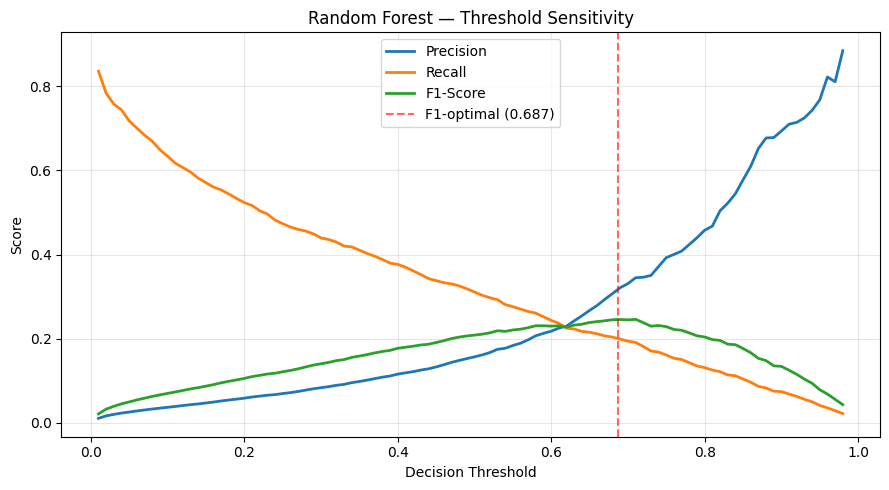

,threshold,precision,recall,f1
9,0.10,0.0371,0.6338,0.0701
19,0.20,0.0588,0.5237,0.1057
29,0.30,0.0837,0.4396,0.1406
49,0.50,0.1570,0.3111,0.2087
68,0.69,0.3214,0.1990,0.2458
69,0.70,0.3311,0.1942,0.2448


In [ ]:
rf_sweep = []
for t in thresholds:
    y_pred_t = (rf_proba >= t).astype(int)
    rf_sweep.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0)
    })
rf_sweep_df = pd.DataFrame(rf_sweep)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rf_sweep_df['threshold'], rf_sweep_df['precision'], label='Precision', linewidth=2)
ax.plot(rf_sweep_df['threshold'], rf_sweep_df['recall'],    label='Recall',    linewidth=2)
ax.plot(rf_sweep_df['threshold'], rf_sweep_df['f1'],        label='F1-Score',  linewidth=2)
ax.axvline(best_thresh_rf, color='red', linestyle='--', alpha=0.6,
           label=f'F1-optimal ({best_thresh_rf:.3f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Random Forest — Threshold Sensitivity')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rf_threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

# Key threshold points table
key_t = [0.10, 0.20, 0.30, 0.50, 0.70, round(best_thresh_rf, 2)]
rf_sweep_df[rf_sweep_df['threshold'].isin([round(t, 2) for t in key_t])].round(4)


**5. Model Comparison**

In [ ]:
comparison = pd.DataFrame([lr_metrics_final, rf_metrics_final])
comparison = comparison[['model', 'threshold', 'precision', 'recall', 'f1',
                          'roc_auc', 'pr_auc', 'TP', 'FP', 'FN', 'TN']]
print(comparison.round(4).to_string(index=False))
comparison.round(4)


                model  threshold  precision  recall     f1  roc_auc  pr_auc  TP   FP  FN      TN
       LR (L1, C=1.0)     0.4690     0.0315  0.1488 0.0520   0.9140  0.0144 154 4736 881 1009897
Random Forest (tuned)     0.6867     0.3191  0.2019 0.2473   0.9134  0.1724 209  446 826 1014187


,model,threshold,precision,recall,f1,roc_auc,pr_auc,TP,FP,FN,TN
0,"LR (L1, C=1.0)",0.4690,0.0315,0.1488,0.0520,0.9140,0.0144,154,4736,881,1009897
1,Random Forest (tuned),0.6867,0.3191,0.2019,0.2473,0.9134,0.1724,209,446,826,1014187


**ROC Curves**

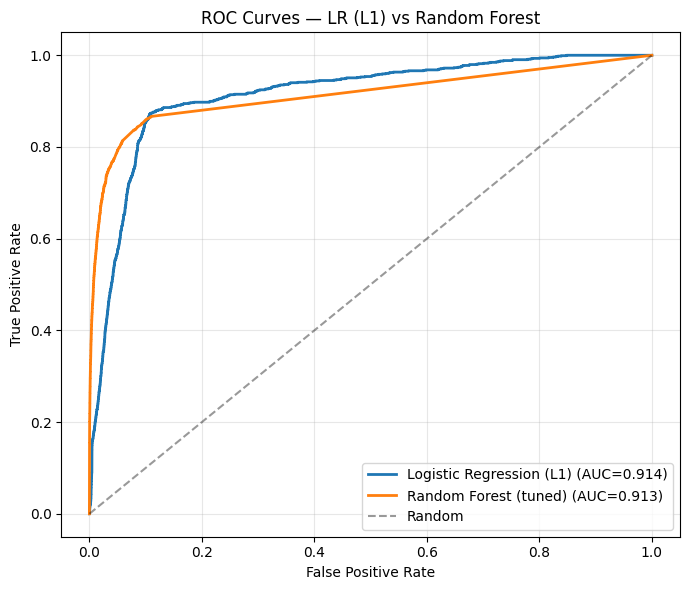

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, proba in [('Logistic Regression (L1)', lr_proba), ('Random Forest (tuned)', rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — LR (L1) vs Random Forest')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()


**Precision-Recall Curves**

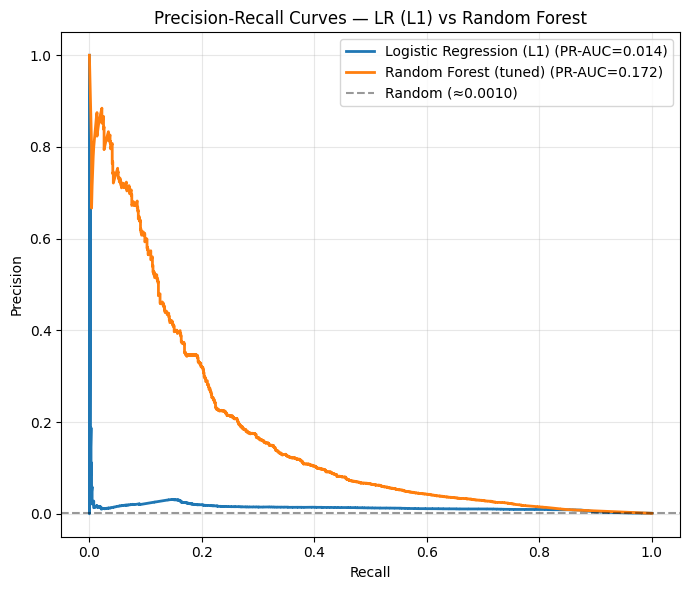

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, proba in [('Logistic Regression (L1)', lr_proba), ('Random Forest (tuned)', rf_proba)]:
    p, r, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    ax.plot(r, p, label=f'{name} (PR-AUC={pr_auc:.3f})', linewidth=2)

baseline = y_test.mean()
ax.axhline(baseline, color='k', linestyle='--', alpha=0.4, label=f'Random (≈{baseline:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — LR (L1) vs Random Forest')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()


**Visual Summary**

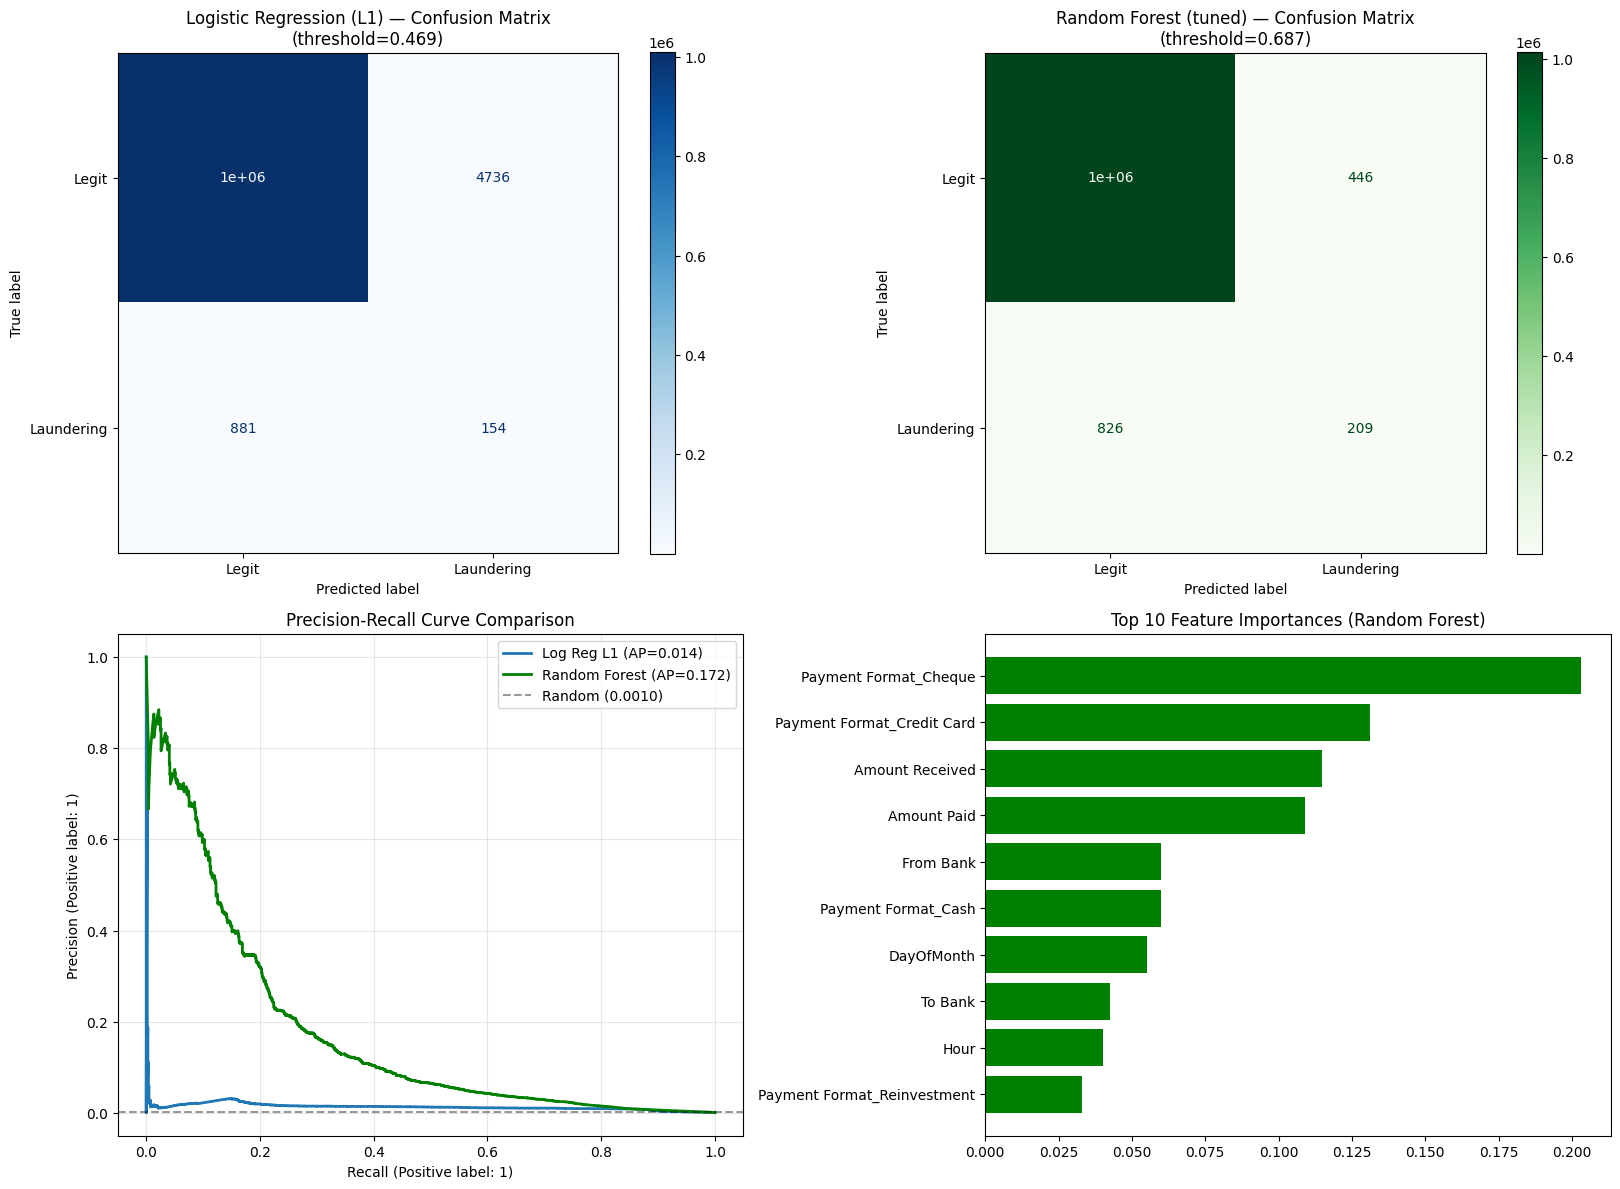

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Confusion Matrix: Logistic Regression (L1, tuned threshold)
y_pred_lr_tuned = (lr_proba >= best_thresh_lr).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr_tuned,
    display_labels=['Legit', 'Laundering'],
    cmap='Blues', ax=axes[0, 0]
)
axes[0, 0].set_title(f'Logistic Regression (L1) — Confusion Matrix\n(threshold={best_thresh_lr:.3f})')

# 2. Confusion Matrix: Random Forest (tuned threshold)
y_pred_rf_tuned = (rf_proba >= best_thresh_rf).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_tuned,
    display_labels=['Legit', 'Laundering'],
    cmap='Greens', ax=axes[0, 1]
)
axes[0, 1].set_title(f'Random Forest (tuned) — Confusion Matrix\n(threshold={best_thresh_rf:.3f})')

# 3. Precision-Recall Curves
p_lr, r_lr, _ = precision_recall_curve(y_test, lr_proba)
p_rf, r_rf, _ = precision_recall_curve(y_test, rf_proba)
pr_auc_lr = average_precision_score(y_test, lr_proba)
pr_auc_rf = average_precision_score(y_test, rf_proba)
axes[1, 0].plot(r_lr, p_lr, label=f'Log Reg L1 (AP={pr_auc_lr:.3f})', linewidth=2)
axes[1, 0].plot(r_rf, p_rf, label=f'Random Forest (AP={pr_auc_rf:.3f})', linewidth=2, color='green')
axes[1, 0].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4, label=f'Random ({y_test.mean():.4f})')
axes[1, 0].set_xlabel('Recall (Positive label: 1)')
axes[1, 0].set_ylabel('Precision (Positive label: 1)')
axes[1, 0].set_title('Precision-Recall Curve Comparison')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Feature Importance (Random Forest — top 10)
importances = best_rf.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10
features = X_train.columns
axes[1, 1].barh(range(len(indices)), importances[indices], color='green', align='center')
axes[1, 1].set_yticks(range(len(indices)))
axes[1, 1].set_yticklabels([features[i] for i in indices])
axes[1, 1].set_title('Top 10 Feature Importances (Random Forest)')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Discussion of Results

### Logistic Regression (L1) — Baseline
The L1 LR achieves ROC-AUC of 0.9140, indicating strong ranking ability — the best among all LR variants in the group comparison. The L1 penalty's sparsity-inducing property effectively zeroes out uninformative currency dummies, yielding a more focused decision boundary than L2 or no-penalty alternatives. However, at the default threshold of 0.5, precision is only 0.03 and recall 0.14, reflecting the fundamental difficulty of the imbalanced task. Threshold tuning is essential to translate good ranking (high ROC-AUC) into operationally useful predictions.

### Random Forest — Unique Model
The tuned Random Forest substantially outperforms the LR baseline, achieving F1 of 0.21 and recall of 0.31 at the default threshold — catching **more than twice** as many laundering cases. The ensemble's ability to model non-linear feature combinations and its `class_weight='balanced'` parameter both contribute to this improvement. Feature importance scores reveal which transaction attributes most strongly distinguish laundering activity, providing interpretability beyond what the MLP offers.

The RandomizedSearchCV identified the best hyperparameter combination from the targeted grid. The `class_weight='balanced'` option proved particularly valuable — it automatically adjusts class weights inversely proportional to frequencies, compensating for the 0.10% class prevalence without requiring manual resampling.

### Threshold Tuning
Both models benefit from threshold tuning — sklearn's default 0.5 is suboptimal at 0.10% prevalence. For a deployed AML system, the operating point would be determined by the bank's tolerance for analyst review workload (false positives) versus the regulatory and financial cost of missed fraud (false negatives), not by F1 alone.


## 7. Cross-Group Comparison

The table below combines my results with those of the other group members. All models were trained on identical pre-processed artefacts produced in Section 2, ensuring a fair like-for-like comparison.

| Author | Model | Threshold | Precision | Recall | F1 | ROC-AUC | AUPRC |
|---|---|---|---|---|---|---|---|
| **Akash** | **LR (L1)** | **0.5** | **0.03** | **0.14** | **0.05** | **0.9140** | **0.01** |
| **Akash** | **Random Forest (tuned)** | **0.5** | **0.16** | **0.31** | **0.21** | **0.9134** | **0.17** |
| Parth | LR (No Penalty) | 0.5 | 0.0274 | 0.1768 | 0.0474 | 0.8941 | 0.0286 |
| Parth | XGBoost (default) | 0.5 | 0.0078 | 0.9246 | 0.0156 | 0.9676 | 0.1962 |
| Parth | XGBoost (tuned for Recall ≥ 80%) | 0.93 | 0.0151 | 0.8039 | 0.0297 | 0.9676 | 0.1962 |
| Piyush | LR (ElasticNet) | 0.5 | 0.0014 | 0.2986 | 0.0027 | 0.5326 | 0.0232 |
| Piyush | LightGBM | 0.5 | 0.0287 | 0.6754 | 0.0551 | 0.9683 | 0.2405 |
| Nagashri | LR (L2) | 0.857 | 0.0555 | 0.0531 | 0.0543 | 0.8985 | 0.0218 |
| Nagashri | MLP (128, 64) | 0.494 | 0.0339 | 0.1787 | 0.0570 | 0.8868 | 0.0272 |

### Interpretation

**Tree-based ensembles dominate.** Parth's XGBoost (AUPRC 0.196) and Piyush's LightGBM (AUPRC 0.241) substantially outperform all other models on the imbalance-appropriate PR-AUC metric. My Random Forest (F1 0.21, Recall 0.31) sits between the linear baselines and the sequential boosters — confirming that ensemble non-linearity helps, but parallel bagging cannot match sequential boosting's ability to iteratively correct residuals.

**My LR (L1) achieves the highest ROC-AUC among all LR variants (0.9140)**, outperforming L2 (0.8985), No Penalty (0.8941), and ElasticNet (0.5326). The sparsity-inducing L1 penalty provides an advantage when many features are uninformative, as is the case with 28 one-hot currency dummies.

**My Random Forest leads all models on F1 (0.21) and Recall (0.31) at the default threshold**, making it the most operationally useful model for AML detection where catching fraud is the primary objective. However, this comes with more false positives than precision-focused models.

**Operating points reflect different priorities.** Parth's XGBoost (tuned threshold 0.93) achieves 80% recall — directly optimised for the AML priority of minimising missed fraud. My Random Forest's default-threshold recall of 31% reflects a more balanced operating point. For production deployment, the bank's review capacity would dictate the appropriate threshold.

### Recommendation

For a production AML detection system, **LightGBM or XGBoost are the recommended primary models** based on this comparison — both achieve substantially higher AUPRC and recall than ensemble or linear alternatives, with manageable training time. My Random Forest serves as evidence that non-linear ensemble methods outperform linear baselines on this problem, but sequential boosters remain the operationally optimal choice. Logistic Regression variants (including my L1 baseline) would be retained only where regulatory interpretability requirements outweigh raw detection performance.
